In [1]:
from pathlib import Path
import sys
import json
import os
from datetime import datetime

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import yaml


In [10]:
def setup_import_paths():
    """
    Matches the idea in train_sp500.py: add your local dataset module folder and src/models
    so that imports work in a notebook.
    """
    p = Path.cwd()
    par = Path.cwd().parent
    sys.path.insert(0, str(par/ "data"))
    sys.path.insert(0, str(par /"src" / "models"))

setup_import_paths()


In [19]:
# --- evaluation target ---
start_date = "2020-01-02"
end_date   = "2024-12-31"
sequence_length = 252
validation_ratio = 0.2
checkpoint = "FINAL_scratch_ckpt_epoch_49_2026-01-12.pt"
ckpt_path = f"../checkpoints/{checkpoint}"

# features must match training order
COLS = ["Open", "High", "Low", "Close", "Volume"]

# sampling
n_samples = 20

# where your training checkpoints are saved
checkpoints_dir = Path("./checkpoints")


In [6]:
def load_config(config_path: str) -> dict:
    with open(config_path, "r") as f:
        return yaml.safe_load(f)

config = load_config("../configs/base_csdi.yaml")
batch_size = int(config["train"]["batch_size"])


In [8]:
def load_all_tickers(data_dir: str, start_date: str, end_date: str, cols=None):
    dfs = []
    pattern = f"*_{start_date}_{end_date}_processed.csv"
    for fp in sorted(Path(data_dir).glob(pattern)):
        df = pd.read_csv(fp)
        if "Date" in df.columns:
            df = df.sort_values("Date").reset_index(drop=True)
        if cols is not None:
            df = df[cols]
        dfs.append(df)
    if len(dfs) == 0:
        raise ValueError(f"No files matched pattern {pattern} in {data_dir}")
    return dfs

dfs = load_all_tickers("../data/sp500_individual", start_date, end_date, cols=COLS)
len(dfs), dfs[0].shape


(486, (1256, 5))

# Create a DataLoader

In [11]:
# this assumes you have data/sp500_data.py with MultiFinancialDataset,
# exactly as in train_sp500.py.
from sp500_data import MultiFinancialDataset

def create_dataloaders_multi(dfs, seq_len, val_rat, batch_size, close_idx=3, forecast_horizon=None):
    if isinstance(dfs, dict):
        dfs_list = list(dfs.values())
    else:
        dfs_list = list(dfs)

    train_parts, val_parts = [], []
    purge = seq_len - 1

    for df in dfs_list:
        if df is None or df.empty:
            continue
        if "Date" in df.columns:
            df = df.sort_values("Date").reset_index(drop=True)

        n = len(df)
        if n < seq_len:
            continue

        split = int(n * (1.0 - val_rat))
        train_end = max(split - purge, seq_len + 1)

        train_df = df.iloc[:train_end].reset_index(drop=True)
        val_df   = df.iloc[split:].reset_index(drop=True)

        if len(train_df) >= seq_len:
            train_parts.append(train_df)
        if len(val_df) >= seq_len:
            val_parts.append(val_df)

    train_dataset = MultiFinancialDataset(train_parts, seq_len=seq_len, close_idx=close_idx, forecast_horizon=forecast_horizon)
    val_dataset   = MultiFinancialDataset(val_parts,   seq_len=seq_len, close_idx=close_idx, forecast_horizon=forecast_horizon)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

train_loader, val_loader = create_dataloaders_multi(
    dfs=dfs,
    seq_len=sequence_length,
    val_rat=validation_ratio,
    batch_size=batch_size,
    close_idx=3,
)


In [12]:
def to_scratch_batch(batch: dict) -> dict:
    """
    Converts MultiFinancialDataset / FinancialDataset batch format to the scratch model input format.

    input:
      observed_data: (B, K, L)
      observed_mask: (B, K, L)
      cond_mask:     (B, K, L)
      timepoints:    (L,) or (B, L)

    output (scratch):
      observed_data: (B, L, K)
      observed_mask: (B, L, K)
      cond_mask:     (B, L, K)
      timepoints:    (B, L)
    """
    x = batch["observed_data"]
    obs_mask = batch["observed_mask"]
    cond = batch["cond_mask"]
    tp = batch["timepoints"]

    x = x.permute(0, 2, 1).contiguous()
    obs_mask = obs_mask.permute(0, 2, 1).contiguous()
    cond = cond.permute(0, 2, 1).contiguous()

    if tp.dim() == 1:
        tp = tp.unsqueeze(0).expand(x.shape[0], -1).contiguous()
    elif tp.dim() != 2:
        raise ValueError(f"Unexpected timepoints shape: {tp.shape}")

    return {
        "observed_data": x.float(),
        "observed_mask": obs_mask.float(),
        "cond_mask": cond.float(),
        "timepoints": tp.float(),
    }


In [13]:
from csdi_scratch import CSDIFromScratch, DiffusionConfig  # from src/models via setup_import_paths()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [17]:
# ckpt_path = find_latest_checkpoint(checkpoints_dir)
ckpt_path


'FINAL_scratch_ckpt_epoch_49_2026-01-12.pt'

In [20]:
ckpt = torch.load(ckpt_path, map_location="cpu")

K = int(ckpt["K"])
cfg = DiffusionConfig(**ckpt["cfg"])

model = CSDIFromScratch(K=K, cfg=cfg).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print("Loaded checkpoint:", ckpt_path)
print("K =", K)
print("cfg =", cfg)


Loaded checkpoint: ../checkpoints/FINAL_scratch_ckpt_epoch_49_2026-01-12.pt
K = 5
cfg = DiffusionConfig(num_steps=50, beta_start=0.0001, beta_end=0.5, d_model=128, nhead=4, num_layers=4, dim_feedforward=256, dropout=0.1)


c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


# Run imputation

In [21]:
@torch.no_grad()
def run_imputation_on_one_batch(model, loader, n_samples: int):
    batch = next(iter(loader))
    batch_s = to_scratch_batch(batch)
    batch_s = {k: v.to(device) for k, v in batch_s.items()}

    # (B, S, L, K)
    samples = model.impute(batch_s, n_samples=n_samples)

    # build target mask = observed - conditioned
    obs_mask = batch_s["observed_mask"]
    cond_mask = (batch_s["cond_mask"] * obs_mask)
    target_mask = (obs_mask - cond_mask).clamp(0.0, 1.0)

    payload = {
        "samples": samples.detach().cpu(),               # (B, S, L, K)
        "observed": batch_s["observed_data"].cpu(),      # (B, L, K)
        "observed_mask": obs_mask.cpu(),                 # (B, L, K)
        "cond_mask": cond_mask.cpu(),                    # (B, L, K)
        "target_mask": target_mask.cpu(),                # (B, L, K)
        "timepoints": batch_s["timepoints"].cpu(),       # (B, L)
        "n_samples": n_samples,
    }
    return payload

payload = run_imputation_on_one_batch(model, val_loader, n_samples=n_samples)
{k: (v.shape if torch.is_tensor(v) else v) for k, v in payload.items()}


{'samples': torch.Size([8, 20, 252, 5]),
 'observed': torch.Size([8, 252, 5]),
 'observed_mask': torch.Size([8, 252, 5]),
 'cond_mask': torch.Size([8, 252, 5]),
 'target_mask': torch.Size([8, 252, 5]),
 'timepoints': torch.Size([8, 252]),
 'n_samples': 20}

# Save outputs

In [22]:
out_dir = Path("../outputs")
out_dir.mkdir(parents=True, exist_ok=True)

today_str = datetime.now().strftime("%Y-%m-%d")
out_path = out_dir / f"sp500_{start_date}_{end_date}_{today_str}_scratch_out.pt"

torch.save(payload, out_path)
out_path


WindowsPath('../outputs/sp500_2020-01-02_2024-12-31_2026-01-13_scratch_out.pt')

# Load outputs back

In [23]:
loaded = torch.load(out_path, map_location="cpu")

samples = loaded["samples"]          # (B, S, L, K)
observed = loaded["observed"]        # (B, L, K)
target_mask = loaded["target_mask"]  # (B, L, K)
timepoints = loaded["timepoints"]    # (B, L)

samples.shape, observed.shape, target_mask.shape, timepoints.shape


(torch.Size([8, 20, 252, 5]),
 torch.Size([8, 252, 5]),
 torch.Size([8, 252, 5]),
 torch.Size([8, 252]))

# Load outputs back

In [24]:
loaded = torch.load(out_path, map_location="cpu")

samples = loaded["samples"]          # (B, S, L, K)
observed = loaded["observed"]        # (B, L, K)
target_mask = loaded["target_mask"]  # (B, L, K)
timepoints = loaded["timepoints"]    # (B, L)

samples.shape, observed.shape, target_mask.shape, timepoints.shape


(torch.Size([8, 20, 252, 5]),
 torch.Size([8, 252, 5]),
 torch.Size([8, 252, 5]),
 torch.Size([8, 252]))

# Visualization

Masked points metrics: RMSE=0.0204365, MAE=0.0160177


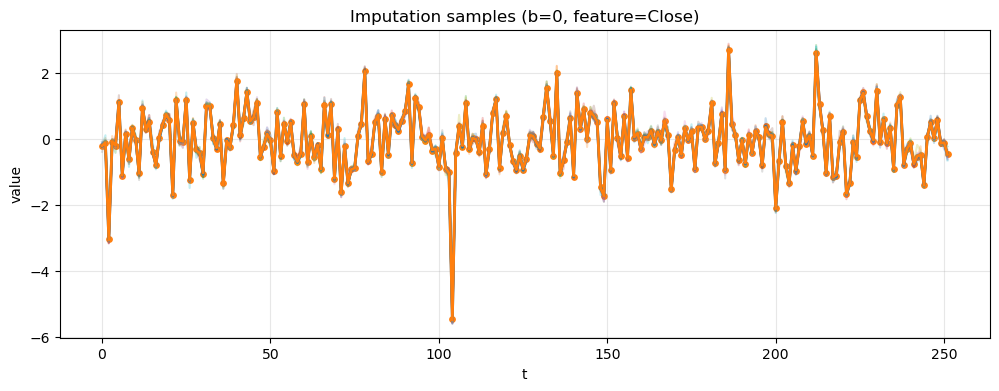

In [25]:
def plot_imputation(
    samples: torch.Tensor,       # (B, S, L, K)
    observed: torch.Tensor,      # (B, L, K)
    target_mask: torch.Tensor,   # (B, L, K)
    b: int = 0,
    k: int = 3,                  # default: "Close" if COLS uses [Open,High,Low,Close,Volume]
    n_show: int = 20,
):
    S = samples[b, :, :, k].numpy()         # (S, L)
    x = observed[b, :, k].numpy()           # (L,)
    tm = target_mask[b, :, k].numpy().astype(bool)  # (L,)

    pred_mean = S.mean(axis=0)              # (L,)
    lo = np.quantile(S, 0.10, axis=0)
    hi = np.quantile(S, 0.90, axis=0)

    # metrics on masked positions
    if tm.any():
        rmse = np.sqrt(np.mean((pred_mean[tm] - x[tm]) ** 2))
        mae = np.mean(np.abs(pred_mean[tm] - x[tm]))
        print(f"Masked points metrics: RMSE={rmse:.6g}, MAE={mae:.6g}")
    else:
        print("No masked target points found (target_mask all zeros).")

    plt.figure(figsize=(12, 4))
    for i in range(min(n_show, S.shape[0])):
        plt.plot(S[i], alpha=0.25)

    plt.plot(x, linewidth=2)                # true
    plt.plot(pred_mean, linewidth=2)        # mean
    plt.fill_between(np.arange(len(x)), lo, hi, alpha=0.2)

    # highlight masked points
    idx = np.where(tm)[0]
    if len(idx) > 0:
        plt.scatter(idx, x[idx], s=15)

    plt.title(f"Imputation samples (b={b}, feature={COLS[k]})")
    plt.xlabel("t")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_imputation(samples, observed, target_mask, b=0, k=3, n_show=20)


# Visualization 2

In [27]:
import numpy as np

def _r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

def _crps_from_samples(samples_1d, y_true_1d):
    """
    samples_1d: (S, T) samples
    y_true_1d:  (T,) truth
    CRPS approx: E|X - y| - 0.5 E|X - X'|
    """
    S, T = samples_1d.shape
    term1 = np.mean(np.abs(samples_1d - y_true_1d[None, :]), axis=0)  # (T,)
    # pairwise E|X-X'| via subsampling for cost control
    # use up to 200 pairs
    rng = np.random.default_rng(0)
    n_pairs = min(200, S * (S - 1) // 2)
    idx_i = rng.integers(0, S, size=n_pairs)
    idx_j = rng.integers(0, S, size=n_pairs)
    term2 = np.mean(np.abs(samples_1d[idx_i] - samples_1d[idx_j]), axis=0)  # (T,)
    return np.mean(term1 - 0.5 * term2)

def imputation_metrics(samples, observed, target_mask, b=0, k=3, q_lo=0.1, q_hi=0.9):
    """
    samples: (B,S,L,K)
    observed: (B,L,K)
    target_mask: (B,L,K) 1 where imputed
    """
    S = samples[b, :, :, k].numpy()     # (S,L)
    x = observed[b, :, k].numpy()       # (L,)
    tm = target_mask[b, :, k].numpy().astype(bool)

    if not tm.any():
        return {"error": "No masked target points (target_mask all zeros)."}

    y_true = x[tm]
    pred_mean = S.mean(axis=0)[tm]
    pred_med  = np.quantile(S, 0.5, axis=0)[tm]
    lo = np.quantile(S, q_lo, axis=0)[tm]
    hi = np.quantile(S, q_hi, axis=0)[tm]

    rmse = np.sqrt(np.mean((pred_mean - y_true)**2))
    mae  = np.mean(np.abs(pred_mean - y_true))
    mape = np.mean(np.abs((pred_mean - y_true) / (np.abs(y_true) + 1e-8)))
    r2   = _r2(y_true, pred_mean)

    coverage = np.mean((y_true >= lo) & (y_true <= hi))
    width    = np.mean(hi - lo)

    # CRPS on only masked timepoints: build samples restricted to tm
    crps = _crps_from_samples(S[:, tm], y_true)

    return {
        "rmse_mean": rmse,
        "mae_mean": mae,
        "mape_mean": mape,
        "r2_mean": r2,
        f"coverage_{int((q_hi-q_lo)*100)}%": coverage,
        f"avg_width_{int((q_hi-q_lo)*100)}%": width,
        "crps": crps,
        "n_masked": int(np.sum(tm)),
        "pred_mean_bias": float(np.mean(pred_mean - y_true)),
        "pred_med_mae": float(np.mean(np.abs(pred_med - y_true))),
    }

m = imputation_metrics(samples, observed, target_mask, b=0, k=3, q_lo=0.1, q_hi=0.9)
m


{'rmse_mean': 0.020436535,
 'mae_mean': 0.01601769,
 'mape_mean': 0.16287898,
 'r2_mean': 0.9994578358018771,
 'coverage_80%': 1.0,
 'avg_width_80%': 0.1654370705221525,
 'crps': 0.018706303,
 'n_masked': 252,
 'pred_mean_bias': 0.0073398808017373085,
 'pred_med_mae': 0.015155234978125903}

In [28]:
def plot_imputation_richer(samples, observed, target_mask, b=0, k=3, n_show=30):
    S = samples[b, :, :, k].numpy()         # (S, L)
    x = observed[b, :, k].numpy()           # (L,)
    tm = target_mask[b, :, k].numpy().astype(bool)

    pred_mean = S.mean(axis=0)
    pred_med  = np.quantile(S, 0.5, axis=0)
    lo80, hi80 = np.quantile(S, 0.10, axis=0), np.quantile(S, 0.90, axis=0)
    lo90, hi90 = np.quantile(S, 0.05, axis=0), np.quantile(S, 0.95, axis=0)

    # metrics (masked)
    stats = imputation_metrics(samples, observed, target_mask, b=b, k=k, q_lo=0.1, q_hi=0.9)

    plt.figure(figsize=(13, 4))
    for i in range(min(n_show, S.shape[0])):
        plt.plot(S[i], alpha=0.15)
    plt.plot(x, linewidth=2, label="true")
    plt.plot(pred_mean, linewidth=2, label="sample mean")
    plt.plot(pred_med, linewidth=2, label="sample median")
    plt.fill_between(np.arange(len(x)), lo80, hi80, alpha=0.20, label="80% PI")
    plt.fill_between(np.arange(len(x)), lo90, hi90, alpha=0.12, label="90% PI")

    idx = np.where(tm)[0]
    if len(idx) > 0:
        plt.scatter(idx, x[idx], s=18, label="masked points")

    plt.title(f"b={b}, feature={COLS[k]} | RMSE={stats.get('rmse_mean', np.nan):.4g} | CRPS={stats.get('crps', np.nan):.4g}")
    plt.xlabel("t")
    plt.ylabel("value")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    # residuals on masked points
    if len(idx) > 0:
        res = (pred_mean[idx] - x[idx])
        plt.figure(figsize=(13, 2.5))
        plt.plot(idx, res, marker="o", linewidth=1)
        plt.axhline(0.0)
        plt.title("Residuals on masked points: (mean prediction - true)")
        plt.grid(True, alpha=0.25)
        plt.show()

    return stats

def evaluate_many(samples, observed, target_mask, bs=(0,1,2), ks=(3,)):
    rows = []
    for b in bs:
        for k in ks:
            rows.append({"b": b, "feature": COLS[k], **imputation_metrics(samples, observed, target_mask, b=b, k=k)})
    return rows

rows = evaluate_many(samples, observed, target_mask, bs=tuple(range(min(5, samples.shape[0]))), ks=(0,1,2,3,4))
rows[:3]


[{'b': 0,
  'feature': 'Open',
  'error': 'No masked target points (target_mask all zeros).'},
 {'b': 0,
  'feature': 'High',
  'error': 'No masked target points (target_mask all zeros).'},
 {'b': 0,
  'feature': 'Low',
  'error': 'No masked target points (target_mask all zeros).'}]

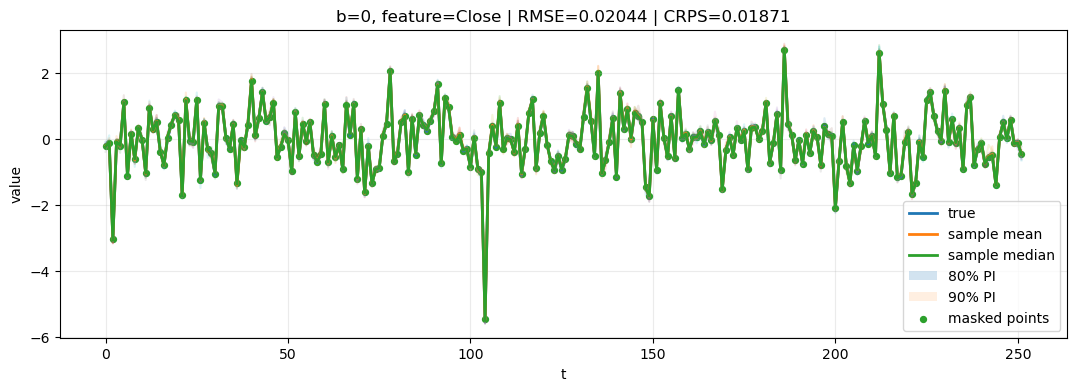

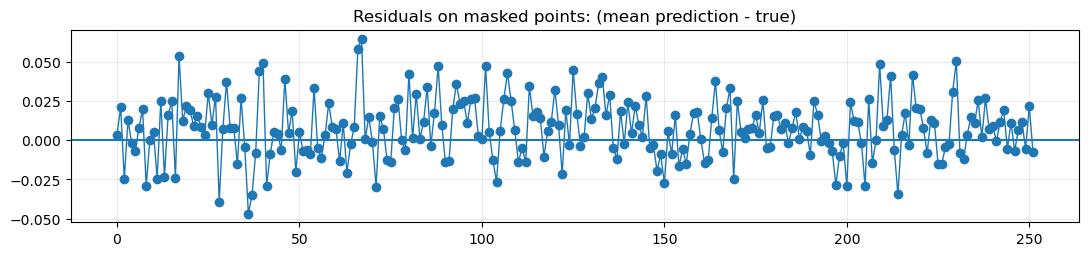

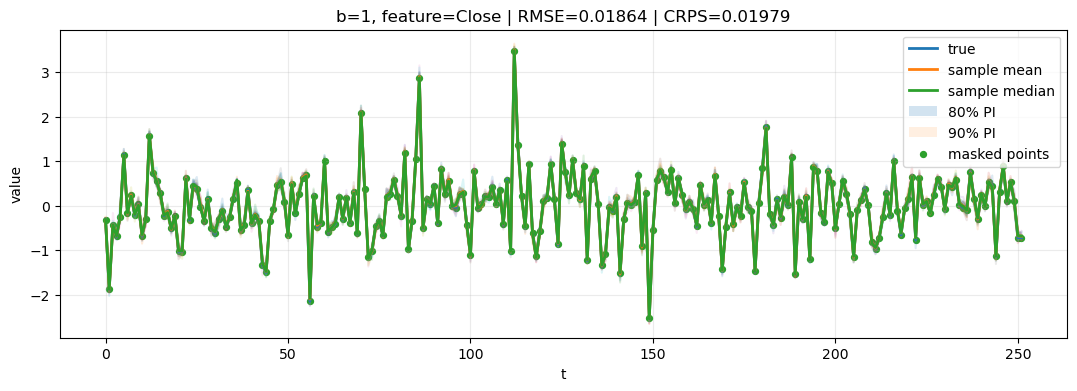

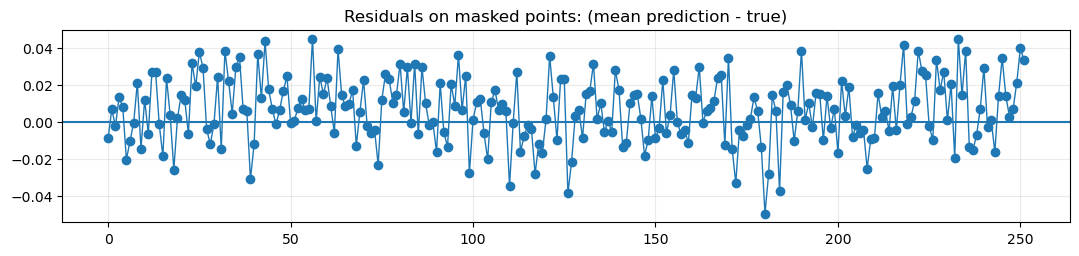

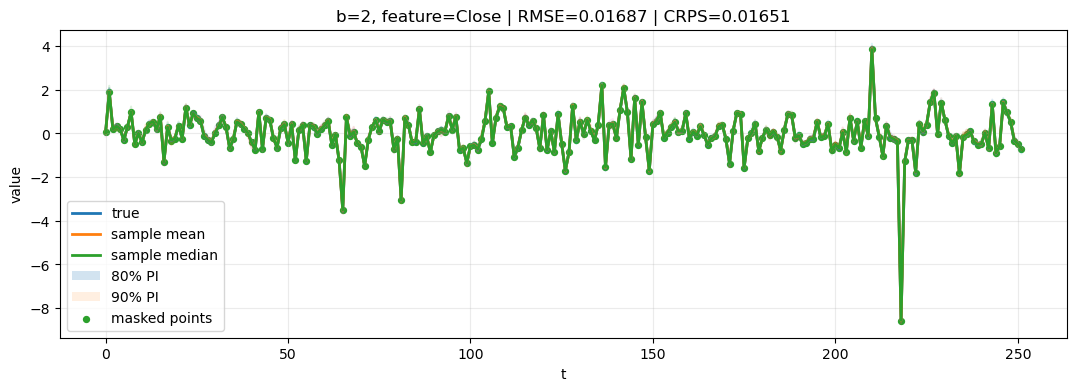

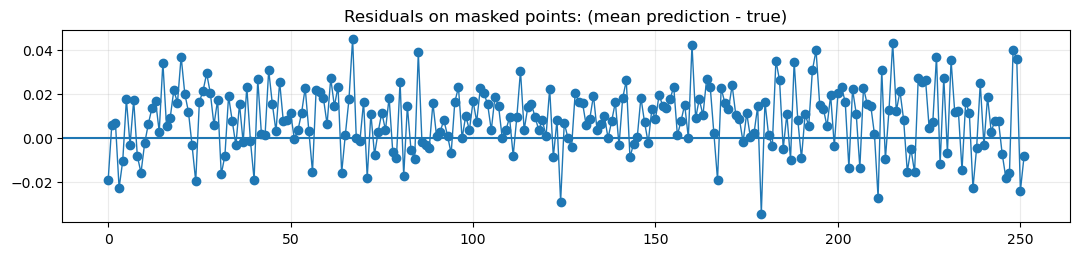

In [29]:
for b in range(min(3, samples.shape[0])):
    for k in [3]:  # Close
        plot_imputation_richer(samples, observed, target_mask, b=b, k=k, n_show=30)


# Stylized facts checks

In [30]:
def log_returns(x, eps=1e-8):
    x = np.asarray(x)
    x = np.maximum(x, eps)
    return np.diff(np.log(x))

def acf(x, max_lag=20):
    x = np.asarray(x)
    x = x - x.mean()
    denom = np.sum(x*x)
    out = []
    for lag in range(1, max_lag+1):
        num = np.sum(x[:-lag] * x[lag:])
        out.append(num / denom if denom > 0 else np.nan)
    return np.array(out)

def skewness(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std() + 1e-12
    return np.mean(((x - m)/s)**3)

def kurtosis_excess(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std() + 1e-12
    return np.mean(((x - m)/s)**4) - 3.0

def leverage_effect(r, lag=1):
    # corr(r_t, r_{t+lag}^2)
    r = np.asarray(r)
    if len(r) <= lag:
        return np.nan
    a = r[:-lag]
    b = (r[lag:]**2)
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.sqrt(np.sum(a*a)) * np.sqrt(np.sum(b*b))) + 1e-12
    return float(np.sum(a*b) / denom)

def stylized_facts_report(samples, observed, target_mask, b=0, k=3, max_lag=20):
    S = samples[b, :, :, k].numpy()     # (S,L)
    x = observed[b, :, k].numpy()
    tm = target_mask[b, :, k].numpy().astype(bool)

    # Focus on a contiguous window? Here we just use full series.
    # If your values are normalized (not prices), switch to simple returns: np.diff(x)
    rx_true = log_returns(x)
    rx_mean = log_returns(S.mean(axis=0))

    # per-sample returns
    rx_s = np.array([log_returns(S[i]) for i in range(S.shape[0])], dtype=float)  # (S, L-1)

    report = {
        "true": {
            "ret_mean": float(np.mean(rx_true)),
            "ret_std": float(np.std(rx_true)),
            "skew": float(skewness(rx_true)),
            "kurt_excess": float(kurtosis_excess(rx_true)),
            "acf_ret_1": float(acf(rx_true, max_lag=1)[0]),
            "acf_sqret_1": float(acf(rx_true**2, max_lag=1)[0]),
            "leverage_lag1": float(leverage_effect(rx_true, lag=1)),
        },
        "sample_mean": {
            "ret_mean": float(np.mean(rx_mean)),
            "ret_std": float(np.std(rx_mean)),
            "skew": float(skewness(rx_mean)),
            "kurt_excess": float(kurtosis_excess(rx_mean)),
            "acf_ret_1": float(acf(rx_mean, max_lag=1)[0]),
            "acf_sqret_1": float(acf(rx_mean**2, max_lag=1)[0]),
            "leverage_lag1": float(leverage_effect(rx_mean, lag=1)),
        },
        "samples_distribution": {
            "skew_mean": float(np.mean([skewness(r) for r in rx_s])),
            "skew_std": float(np.std([skewness(r) for r in rx_s])),
            "kurt_excess_mean": float(np.mean([kurtosis_excess(r) for r in rx_s])),
            "kurt_excess_std": float(np.std([kurtosis_excess(r) for r in rx_s])),
            "acf_ret_1_mean": float(np.mean([acf(r, max_lag=1)[0] for r in rx_s])),
            "acf_sqret_1_mean": float(np.mean([acf(r**2, max_lag=1)[0] for r in rx_s])),
            "leverage_lag1_mean": float(np.mean([leverage_effect(r, lag=1) for r in rx_s])),
        }
    }
    return report

rep = stylized_facts_report(samples, observed, target_mask, b=0, k=3, max_lag=20)
rep


{'true': {'ret_mean': -4.559399258141639e-08,
  'ret_std': 12.702889442443848,
  'skew': 0.018374798819422722,
  'kurt_excess': -1.0891945362091064,
  'acf_ret_1': -0.5853117108345032,
  'acf_sqret_1': 0.12205292284488678,
  'leverage_lag1': 0.0073176817633159915},
 'sample_mean': {'ret_mean': -1.2918297898067976e-07,
  'ret_std': 12.753186225891113,
  'skew': 0.012647346593439579,
  'kurt_excess': -1.0896618366241455,
  'acf_ret_1': -0.578170120716095,
  'acf_sqret_1': 0.1002080962061882,
  'leverage_lag1': 0.018834620616675384},
 'samples_distribution': {'skew_mean': 0.013908859108276295,
  'skew_std': 0.006163821054756864,
  'kurt_excess_mean': -1.0759862358952568,
  'kurt_excess_std': 0.055571868143906605,
  'acf_ret_1_mean': -0.5782971259273286,
  'acf_sqret_1_mean': 0.10601584305555438,
  'leverage_lag1_mean': -0.01236432157526474}}

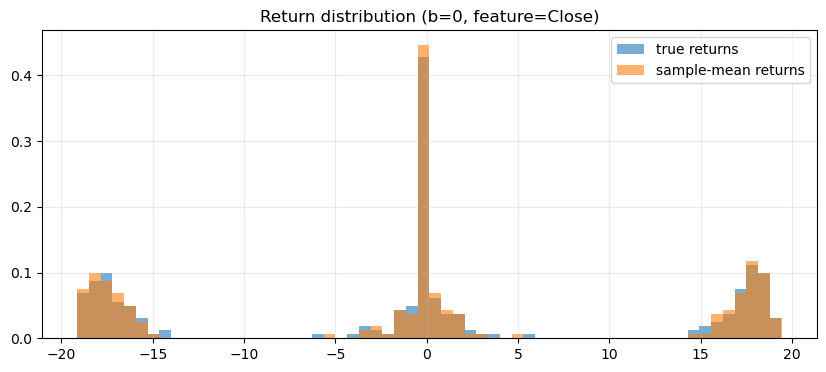

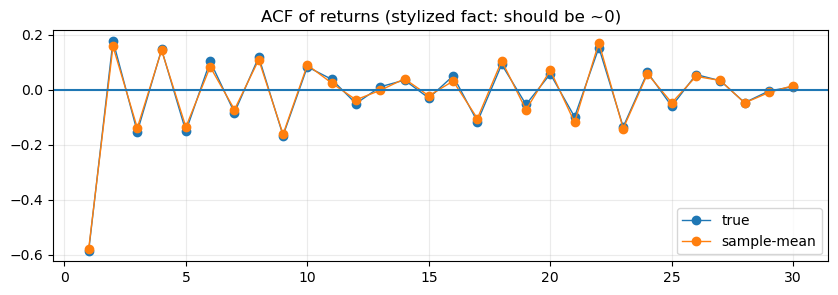

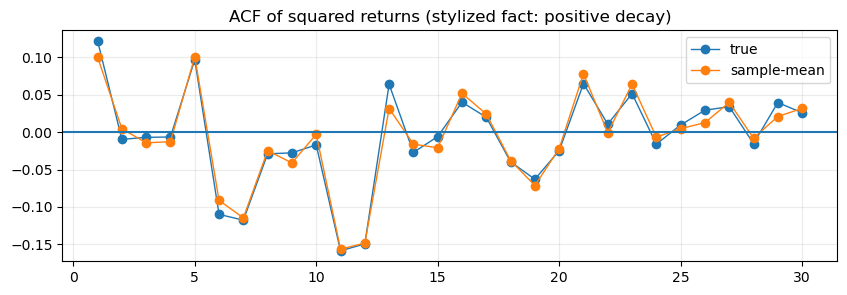

In [31]:
def plot_stylized_facts(samples, observed, b=0, k=3, max_lag=30):
    S = samples[b, :, :, k].numpy()
    x = observed[b, :, k].numpy()

    rx_true = log_returns(x)
    rx_mean = log_returns(S.mean(axis=0))

    # histogram of returns
    plt.figure(figsize=(10,4))
    plt.hist(rx_true, bins=60, alpha=0.6, density=True, label="true returns")
    plt.hist(rx_mean, bins=60, alpha=0.6, density=True, label="sample-mean returns")
    plt.title(f"Return distribution (b={b}, feature={COLS[k]})")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    # ACF of returns
    a1 = acf(rx_true, max_lag=max_lag)
    a2 = acf(rx_mean, max_lag=max_lag)

    plt.figure(figsize=(10,3))
    plt.plot(np.arange(1, max_lag+1), a1, marker="o", linewidth=1, label="true")
    plt.plot(np.arange(1, max_lag+1), a2, marker="o", linewidth=1, label="sample-mean")
    plt.axhline(0.0)
    plt.title("ACF of returns (stylized fact: should be ~0)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    # ACF of squared returns (volatility clustering)
    b1 = acf(rx_true**2, max_lag=max_lag)
    b2 = acf(rx_mean**2, max_lag=max_lag)

    plt.figure(figsize=(10,3))
    plt.plot(np.arange(1, max_lag+1), b1, marker="o", linewidth=1, label="true")
    plt.plot(np.arange(1, max_lag+1), b2, marker="o", linewidth=1, label="sample-mean")
    plt.axhline(0.0)
    plt.title("ACF of squared returns (stylized fact: positive decay)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

plot_stylized_facts(samples, observed, b=0, k=3, max_lag=30)
